# Dynamic Programming: Value Iteration

This notebook runs full value iteration on a deterministic GridWorld environment and visualizes the final value function, the extracted policy, combined overlays, and convergence history.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(".."))

from envs.grid_world import GridWorld
from algorithms.value_iteration import value_iteration
from utils import (
    plot_value_grid,
    plot_policy_arrows,
    plot_value_and_policy,
    plot_convergence_comparison,
)

%matplotlib inline

## Environment Setup

We use a deterministic GridWorld with reproducible terminal states and a random initial value function.

In [2]:
env = GridWorld(n_rows=10, n_cols=15, seed=2026)

gamma = 0.95
seed = 84

print("Environment Configuration:")
print(f"  - Total Grid States: {len(env.states)}")
print(f"  - Terminal States: {env.terminal_states}")
print(f"  - Non-Terminal States: {len(env.non_terminal_states)}")
print(f"  - Available Actions: {env.ACTIONS}")

Environment Configuration:
  - Total Grid States: 150
  - Terminal States: [(2, 0), (5, 6)]
  - Non-Terminal States: 148
  - Available Actions: ['up', 'down', 'left', 'right']


## Value Iteration Run

The algorithm repeatedly applies the Bellman optimality backup until the value function converges.

Value iteration completed in 2220 Bellman backups.
Final delta value: 0.000000


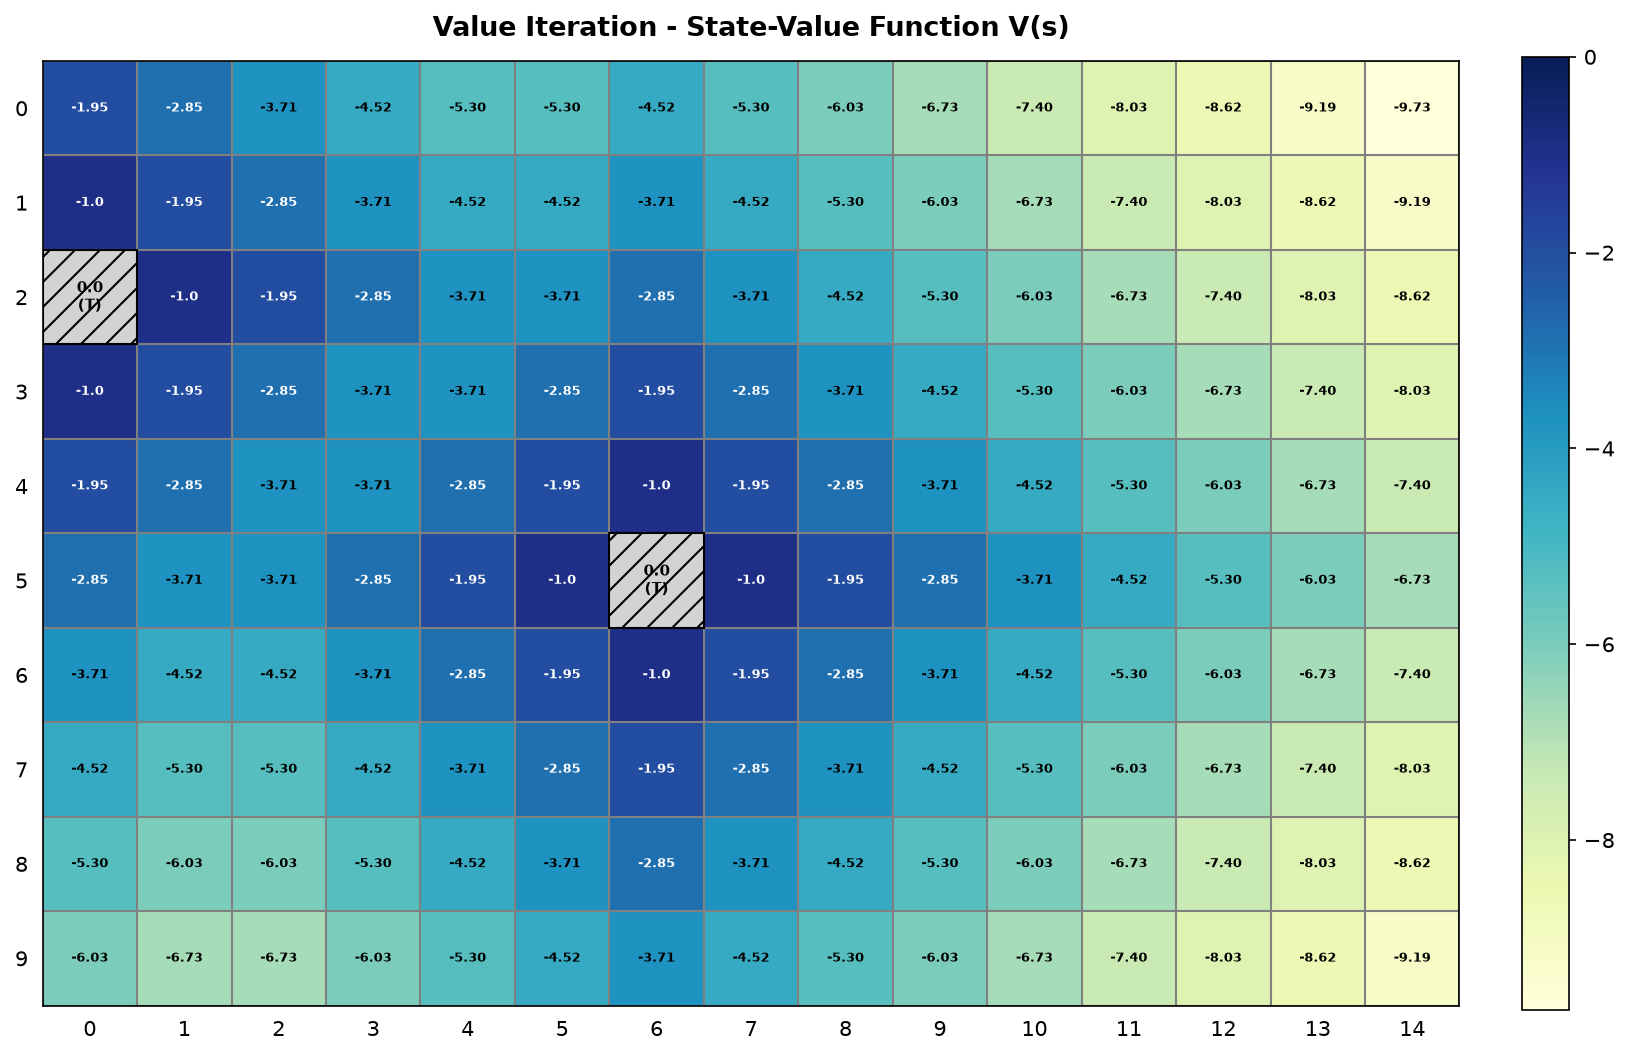

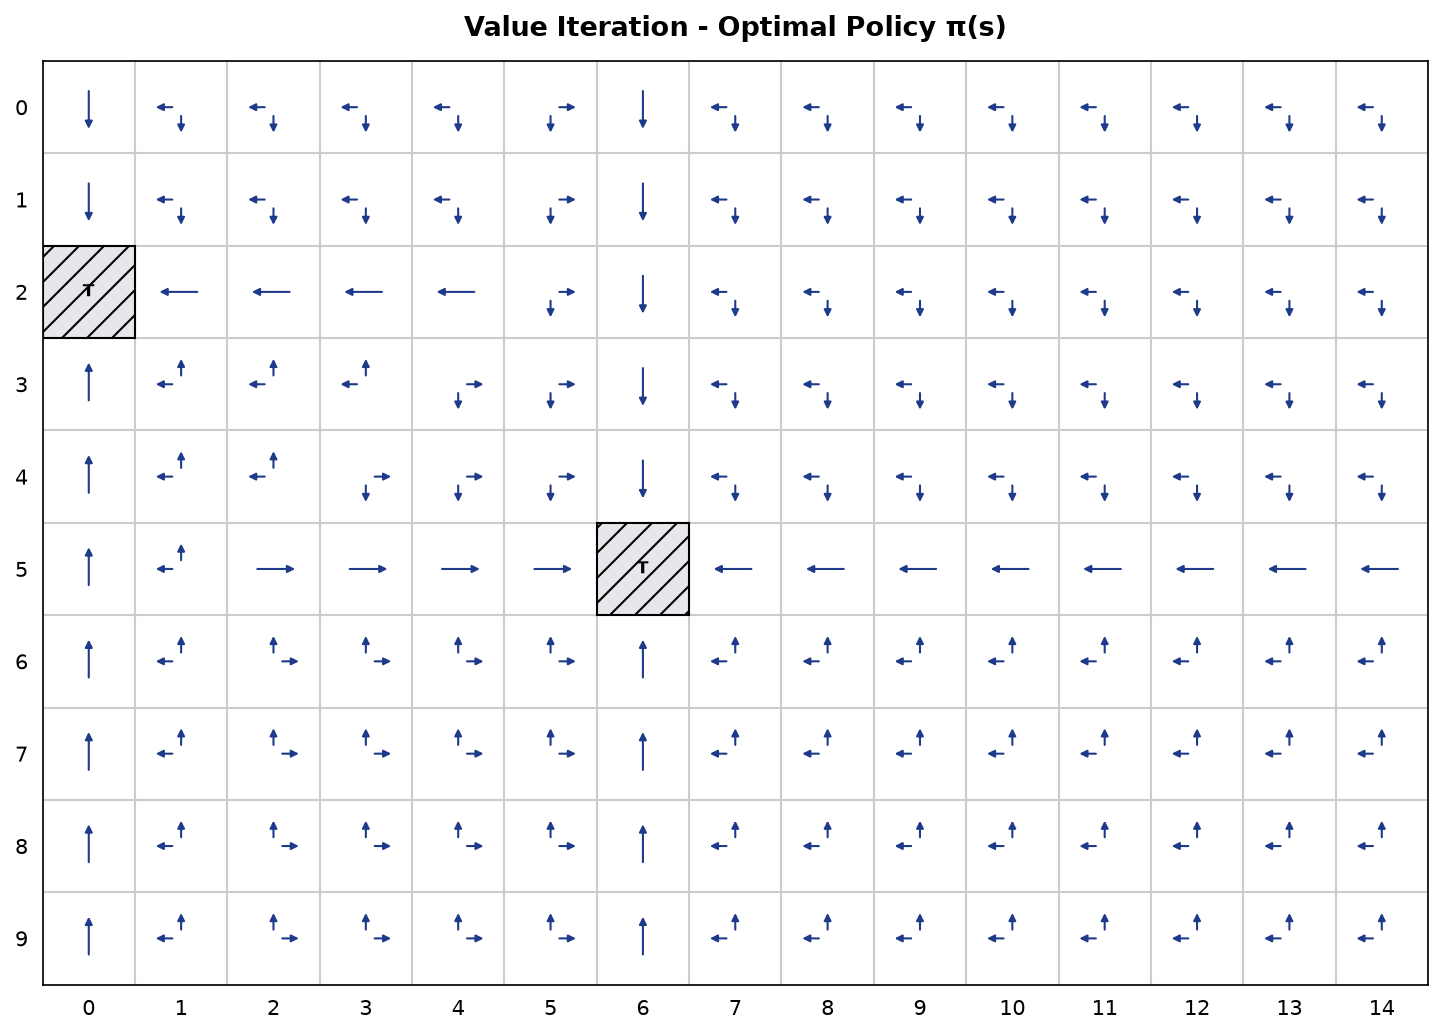

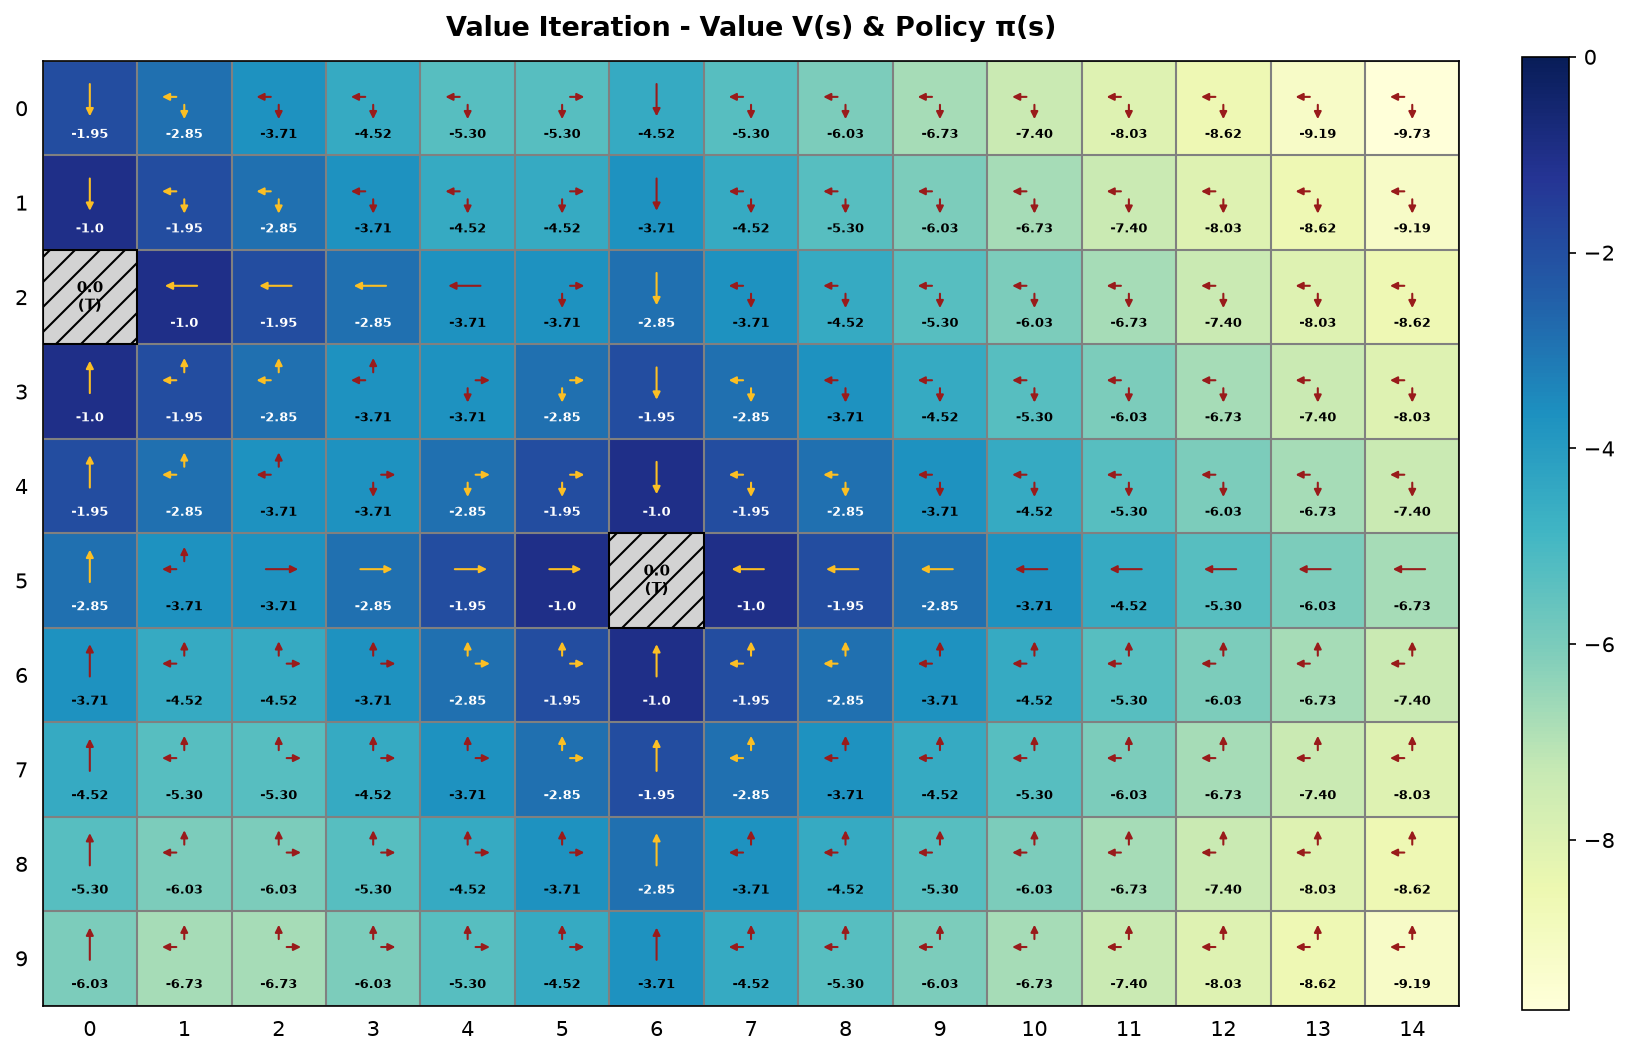

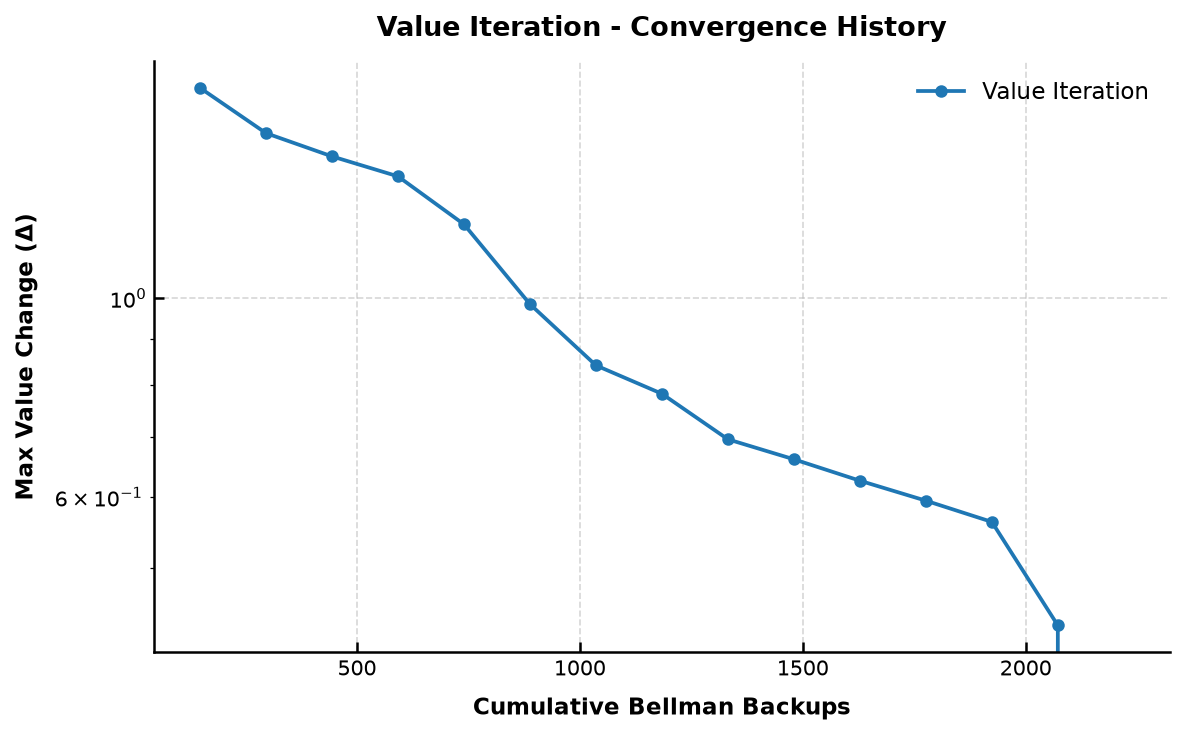

In [3]:
V_vi, pi_vi, history_vi = value_iteration(
    env=env,
    gamma=gamma,
    seed=seed,
)

print(f"Value iteration completed in {history_vi['backup_count'][-1]} Bellman backups.")
print(f"Final delta value: {history_vi['delta'][-1]:.6f}")

fig1, ax1 = plot_value_grid(
    env,
    V_vi,
    title="Value Iteration - State-Value Function V(s)",
)
plt.show()

fig2, ax2 = plot_policy_arrows(
    env,
    pi_vi,
    title="Value Iteration - Optimal Policy π(s)",
)
plt.show()

fig3, ax3 = plot_value_and_policy(
    env,
    V_vi,
    pi_vi,
    title="Value Iteration - Value V(s) & Policy π(s)",
)
plt.show()

fig4, ax4 = plot_convergence_comparison(
    {"Value Iteration": history_vi},
    log_scale=True,
    title="Value Iteration - Convergence History",
)
plt.show()

## Remarks

Value iteration converged to the same optimal solution as policy iteration, but with far fewer Bellman backups. The convergence curve is smoother and the algorithm reaches the stopping condition quickly, which matches the expected behavior of direct Bellman optimality updates in this deterministic GridWorld.